Validation of the leptonic equilibrium against the Fokker-Plank equation solution 
==================================================================================

Jet leptonic
------------

In [1]:
from jetset.jet_model import Jet
from jetset.jet_emitters_factory import InjEmittersFactory

import numpy as np
import matplotlib.pyplot as plt


In [2]:
import jetset
print('tested with',jetset.__version__)

tested with 1.4.0rc3


In [3]:

q_inj = InjEmittersFactory().create_inj_emitters('pl')
q_inj.parameters.gmin.val=100

j = Jet(emitters_distribution=q_inj, emitters_type='electrons', verbose=False)
j.parameters.T_esc_e_primaries.val=2
j.parameters.R.val=1E16
j.parameters.B.val=.2

j.parameters.p.val=2.3
j.parameters.L_inj.val=1E40
j.parameters.gmin.val=1



In [4]:
j.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.000000e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,2.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,p,LE_spectral_slope,,2.300000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,T_esc_e_primaries,escape_time,R / c,2.000000e+00,1.000000e+00,--,False,False


None

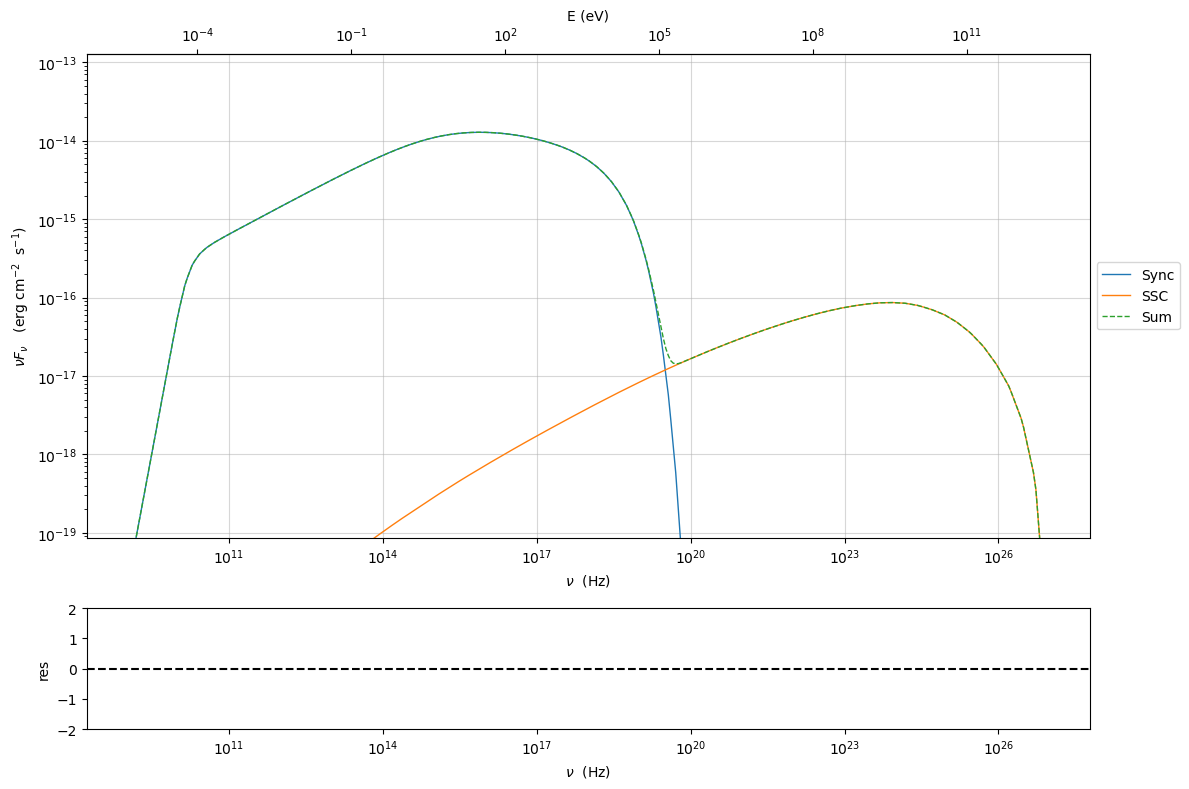

In [5]:
j.eval()
j.plot_model()

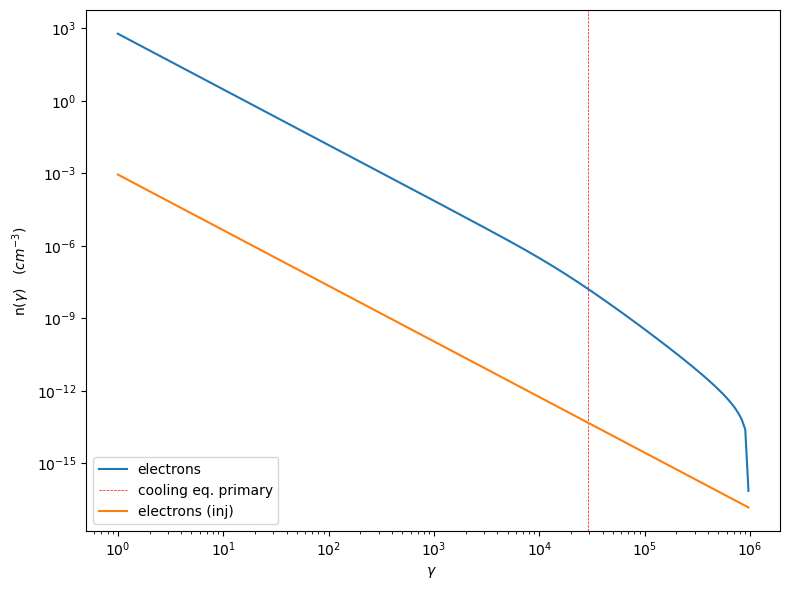

In [6]:
%matplotlib inline
p=j.emitters_distribution.plot()


In [7]:
j.save_model('leptonic_eq.pkl')

In [8]:
j=Jet.load_model('leptonic_eq.pkl')

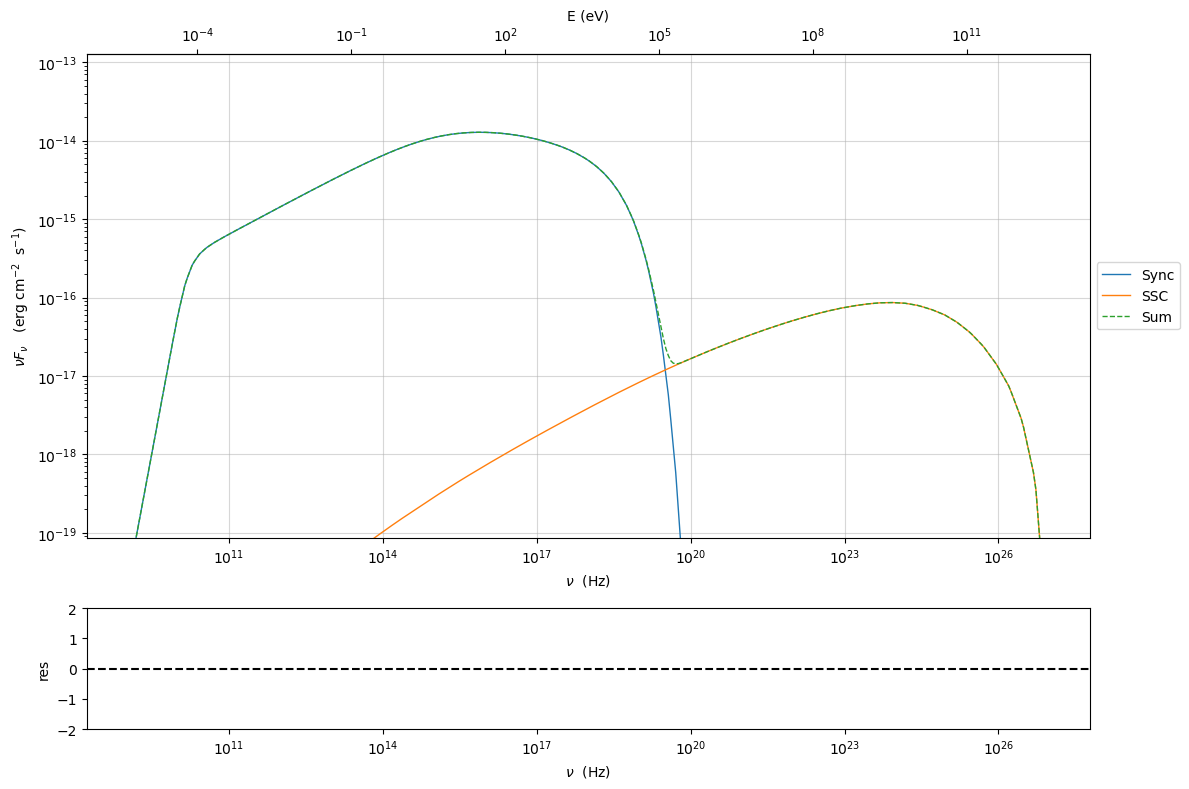

In [9]:
j.eval()
j.plot_model()

setting up the JetTimeEvol model
--------------------------------

In [10]:
gamma_e_evovled=np.copy(j.emitters_distribution.gamma_e)
n_gamma_e_evovled=np.copy(j.emitters_distribution.n_gamma_e)
gamma_e_inj=np.copy(j.emitters_distribution.gamma_e_inj)
n_gamma_e_inj=np.copy(j.emitters_distribution.n_gamma_e_inj)

In [11]:
from jetset.jet_emitters_factory import EmittersFactory
from jetset.jet_emitters import InjEmittersArrayDistribution
q_inj=InjEmittersArrayDistribution(name='array_distr',emitters_type='electrons',gamma_array=gamma_e_inj,n_gamma_array=n_gamma_e_inj,normalize=False)

In [12]:
q_inj.parameters

name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
gmin,low-energy-cut-off,lorentz-factor*,1.000000e+00,1.000000e+00,1.000000e+09,False,False
gmax,high-energy-cut-off,lorentz-factor*,2.000000e+06,1.000000e+00,1.000000e+15,False,False
Q,emitters_density,1 / (s cm3),1.000000e+00,0.000000e+00,--,False,False


None

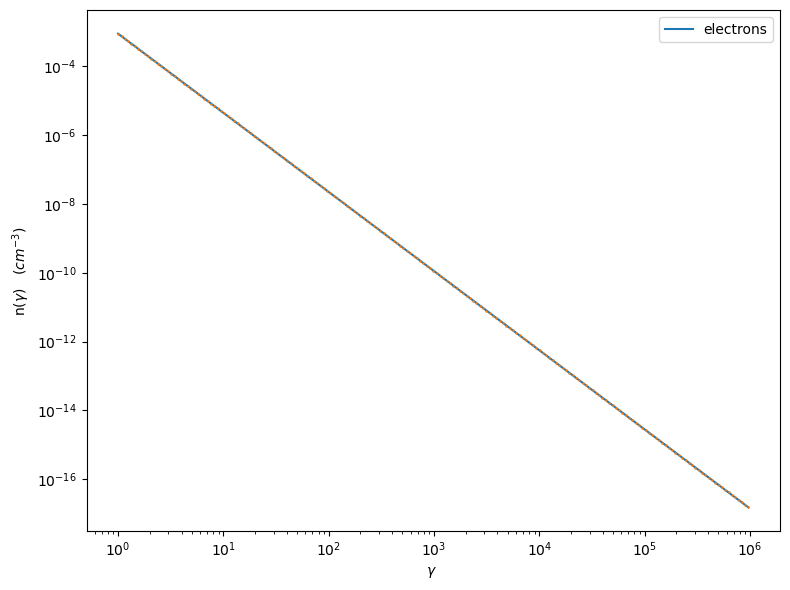

In [13]:
%matplotlib inline
q_inj.update()
p=q_inj.plot()
p.ax.plot(gamma_e_inj, n_gamma_e_inj,'.',ms=1.5)



In [14]:
from jetset.jet_timedep import JetTimeEvol
temp_ev=JetTimeEvol(jet_rad=j,Q_inj=q_inj,only_radiation=True,inplace=True)

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


we use the acc region with escape time equal to radiative region

In [15]:
duration=1E7
duration_acc=0
T_SIZE=np.int32(2E4)

temp_ev.parameters.duration.val=duration

temp_ev.parameters.TStart_Inj.val=0
temp_ev.parameters.TStop_Inj.val=duration
temp_ev.parameters.T_esc_rad.val= 2


temp_ev.parameters.Esc_Index_rad.val=0
temp_ev.parameters.t_size.val=T_SIZE
temp_ev.parameters.num_samples.val=500
temp_ev.IC_cooling='on'
temp_ev.parameters.L_inj.val=0

temp_ev.parameters.gmin_grid.val=1.1
temp_ev.parameters.gmax_grid.val=5E9
temp_ev.parameters.gamma_grid_size.val=400

temp_ev.init_TempEv()
temp_ev.region_expansion='off'
temp_ev.show_model()

--------------------------------------------------------------------------------
JetTimeEvol model description
--------------------------------------------------------------------------------
 
physical setup: 

--------------------------------------------------------------------------------


name,par type,val,units,val*,units*,log
delta t,time,5.000000e+02,s,0.0014989622899999999,R/c,False
log. sampling,time,0.000000e+00,,None,,False
R/c,time,3.335641e+05,s,1.0,R/c,False
IC cooling,,on,,None,,False
Sync cooling,,on,,None,,False
Adiab. cooling,,on,,None,,False
Reg. expansion,,off,,None,,False
Tesc rad,time,6.671282e+05,s,2.0,R/c,False
R_rad rad start,region_position,1.000000e+16,cm,None,,False
R_H rad start,region_position,1.000000e+17,cm,None,,False



model parameters: 

--------------------------------------------------------------------------------


model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_time_ev,duration,time_grid,s,1.000000e+07,0.000000e+00,--,False,True
jet_time_ev,gmin_grid,gamma_grid,,1.100000e+00,0.000000e+00,--,False,True
jet_time_ev,gmax_grid,gamma_grid,,5.000000e+09,0.000000e+00,--,False,True
jet_time_ev,gamma_grid_size,gamma_grid,,4.000000e+02,0.000000e+00,--,False,True
jet_time_ev,TStart_Inj,time_grid,s,0.000000e+00,0.000000e+00,--,False,True
jet_time_ev,TStop_Inj,time_grid,s,1.000000e+07,0.000000e+00,--,False,True
jet_time_ev,T_esc_rad,escape_time,(R/c)*,2.000000e+00,--,--,False,True
jet_time_ev,Esc_Index_rad,fp_coeff_index,,0.000000e+00,--,--,False,True
jet_time_ev,R_rad_start,region_size,cm,1.000000e+16,0.000000e+00,--,False,True
jet_time_ev,R_H_rad_start,region_position,cm,1.000000e+17,0.000000e+00,--,False,True


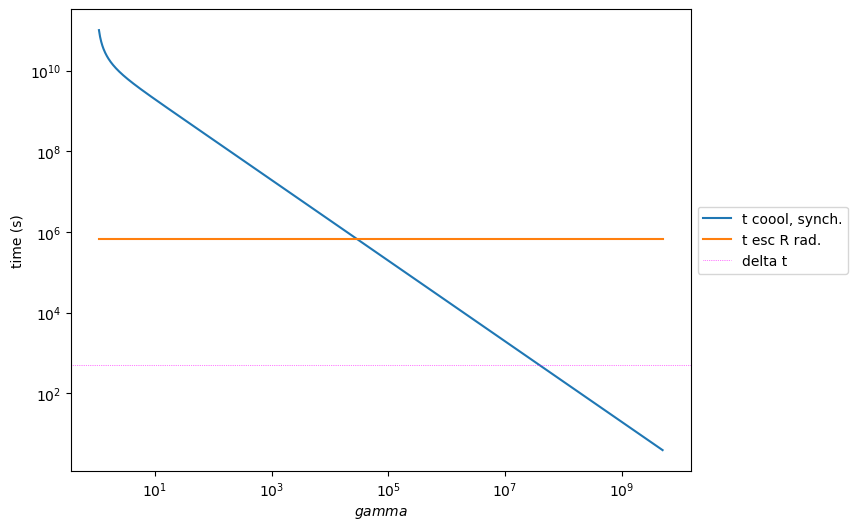

In [16]:
p=temp_ev.plot_pre_run_plot(dpi=100)


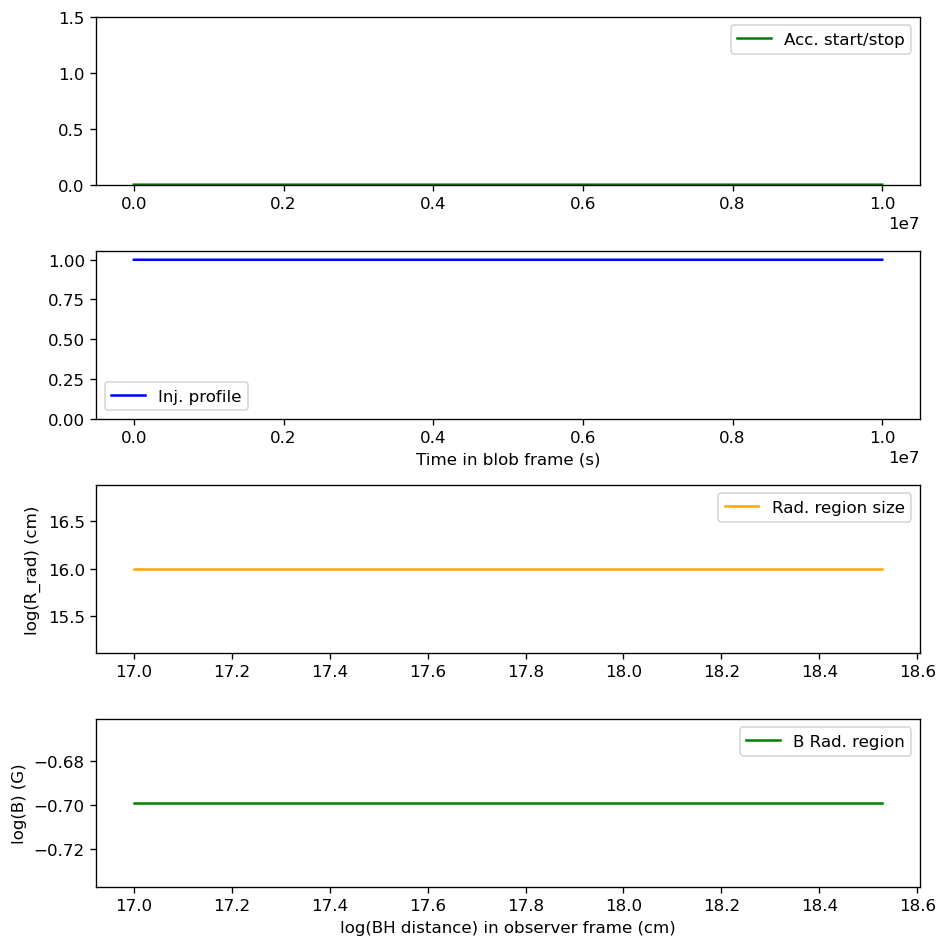

In [17]:
p=temp_ev.plot_time_profile()

we perform the evoltion only for injection and cooling, withou acceleration region

In [18]:
temp_ev.run(only_injection=True,cache_SEDs_acc=False,do_injection=True,cache_SEDs_rad=False)


temporal evolution running


  0%|          | 0/20000 [00:00<?, ?it/s]

temporal evolution completed


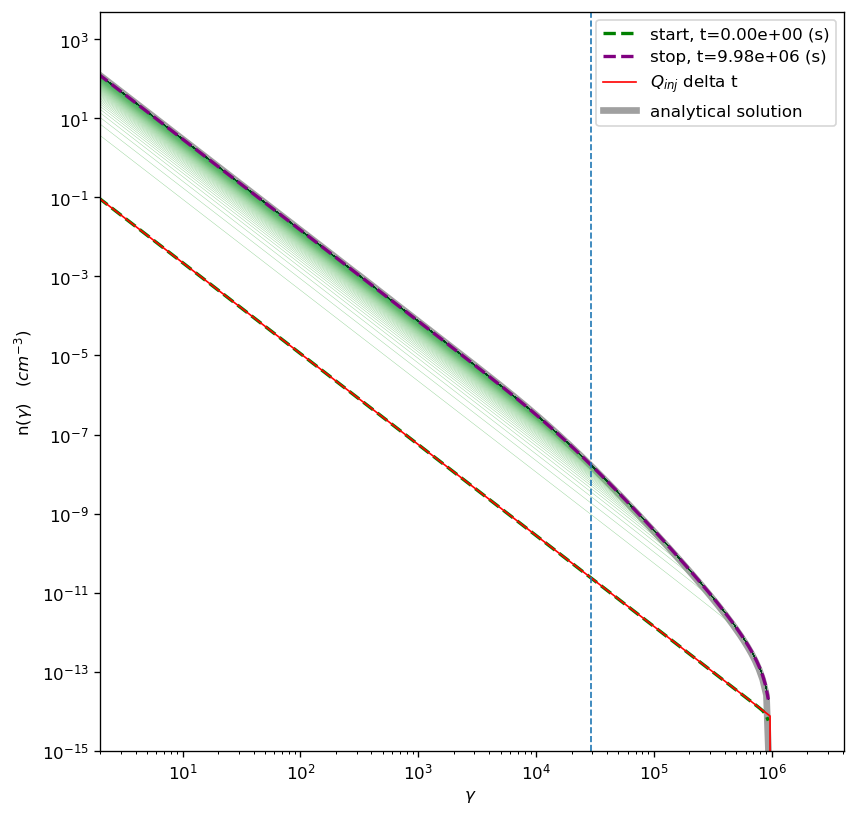

In [19]:
p=temp_ev.plot_tempev_emitters(region='rad',loglog=False,energy_unit='gamma',pow=0,plot_Q_inj=True)
p.ax.plot(gamma_e_evovled,n_gamma_e_evovled,'-',label='analytical solution',lw=4,color='gray',alpha=0.75,zorder=0)
p.ax.axvline(j._blob.emitters.gamma_cooling_eq,ls='--',lw='1')
p.ax.legend()
p.setlim(y_min=1E-15,y_max=5000,x_min=2)


In [20]:
m=n_gamma_e_evovled>0
x_analytical=np.log10(gamma_e_evovled[m])
y_analytical=np.log10(n_gamma_e_evovled[m])

m=temp_ev.rad_region.time_sampled_emitters.n_gamma[-1]>0
x_num=np.log10(temp_ev.rad_region.time_sampled_emitters.gamma[m])
y_num=np.log10(temp_ev.rad_region.time_sampled_emitters.n_gamma[-1][m])

y_analytical_interp = np.interp(x_num, x_analytical,y_analytical, left=np.nan, right=np.nan)

m=~np.isnan(y_analytical_interp)
m=np.logical_and(m,x_num>1)
m=np.logical_and(m,x_num<5.9)

y_analytical_interp=10**y_analytical_interp[m]
x_out=x_num[m]
y_num=10**y_num[m]

In [21]:

d=np.fabs(y_analytical_interp-y_num)/y_num
assert(all(d<0.2))

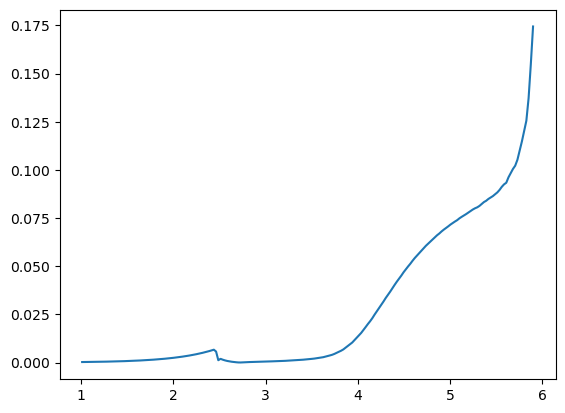

In [22]:
plt.plot(x_out,d)